# Actividad — Escenarios mensuales de Loss Incurred y backtesting cronológico

Este cuaderno completa la actividad a partir del enfoque desarrollado por el equipo y de los notebooks de referencia del curso.

Se construyen tres escenarios acumulados mensuales de **Loss Incurred**:

1. **Creciente:** factores edad-a-edad principalmente mayores que 1.
2. **Decreciente:** factores principalmente menores que 1.
3. **Mixto:** crecimiento temprano y liberación posterior.

La comparación de modelos se hace **sin fuga de información futura** y, dentro de cada escenario, sobre las **mismas claves de predicción bloqueadas**.

> Nota metodológica: `dev_M` se interpreta como una **madurez fija de evaluación**, no como ultimate actuarial infinito.

In [27]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Diseño de los escenarios y horizonte de madurez

La base utiliza 120 períodos de ocurrencia mensuales, de enero de 2016 a diciembre de 2025.  
Cada escenario incorpora:

- tendencia anual moderada de 3.5%;
- estacionalidad de ±8%;
- variación aleatoria lognormal por período de ocurrencia;
- variación moderada en los parámetros de desarrollo entre cohortes.

Los horizontes seleccionados son:

| Escenario | `dev_M` | Justificación |
|---|---:|---|
| Creciente | 60 | La curva alcanza aproximadamente 99% de su nivel de largo plazo alrededor de 48–60 meses. |
| Decreciente | 48 | La mayor parte del ajuste a la baja ya ocurrió; el saldo pendiente es pequeño. |
| Mixto | 48 | Para esa edad ya ocurrió tanto el crecimiento inicial como la mayor parte de la liberación posterior. |

In [28]:
STARTP = pd.Period("2016-01", freq="M")
CURRENTP = pd.Period("2025-12", freq="M")
EVALP = CURRENTP
N = 120

M_BY = {
    "creciente": 60,            # 60
    "decreciente": 48,          # 48
    "mixto": 48,                # 48
}

# Fechas trimestrales de valuación para mantener un rolling-origin cronológico
VALUACIONES = [
    str(p) for p in pd.period_range("2022-06", "2024-12", freq="3M")
]
PRELIMINARES = [
    str(p) for p in pd.period_range("2020-12", "2024-12", freq="3M")
]

print("Fecha actual / scoring:", EVALP)
print("Fechas de valuación:", VALUACIONES)

Fecha actual / scoring: 2025-12
Fechas de valuación: ['2022-06', '2022-09', '2022-12', '2023-03', '2023-06', '2023-09', '2023-12', '2024-03', '2024-06', '2024-09', '2024-12']


In [29]:
def simular_escenario(tipo: str, seed: int = 42, n: int = N) -> tuple[pd.DataFrame, np.ndarray]:
    rng = np.random.default_rng(seed)
    t = np.arange(n, dtype=float)

    # Nivel de largo plazo por período de ocurrencia:
    # tendencia + estacionalidad + ruido.
    nivel = (
        350_000
        * np.exp(0.035 * t / 12)
        * (1 + 0.08 * np.sin(2 * np.pi * t / 12 + 0.4))
        * np.exp(rng.normal(0, 0.10, n))
    )

    matriz = np.full((n, n), np.nan)
    filas = []

    for i in range(n):
        ap = STARTP + i
        dev = np.arange(n - i, dtype=float)

        if tipo == "creciente":
            alpha = max(0.08, 0.13 + rng.normal(0, 0.008))
            n0 = 14 + rng.normal(0, 1.0)

            raw = 1 / (1 + np.exp(-alpha * (dev - n0)))
            raw0 = 1 / (1 + np.exp(alpha * n0))

            proporcion = 0.18 + 0.82 * (raw - raw0) / (1 - raw0)
            proporcion = np.clip(proporcion, 0.18, 1.0)

        elif tipo == "decreciente":
            sobre_reserva = max(0.18, 0.28 + rng.normal(0, 0.025))
            velocidad = max(0.05, 0.075 + rng.normal(0, 0.006))

            # Parte de una estimación inicial sobre-reservada y converge hacia 1.
            proporcion = 1 + sobre_reserva * np.exp(-velocidad * dev)

        elif tipo == "mixto":
            inicio = np.clip(0.62 + rng.normal(0, 0.025), 0.54, 0.70)
            amplitud = np.clip(0.50 + rng.normal(0, 0.025), 0.43, 0.57)
            vel_subida = max(0.11, 0.15 + rng.normal(0, 0.01))

            liberacion = np.clip(0.12 + rng.normal(0, 0.012), 0.09, 0.15)
            vel_bajada = max(0.06, 0.09 + rng.normal(0, 0.008))
            punto_cambio = int(np.clip(round(18 + rng.normal(0, 1.0)), 15, 21))

            proporcion = inicio + amplitud * (1 - np.exp(-vel_subida * dev))
            proporcion -= np.where(
                dev > punto_cambio,
                liberacion * (1 - np.exp(-vel_bajada * (dev - punto_cambio))),
                0,
            )
        else:
            raise ValueError("tipo debe ser creciente, decreciente o mixto")

        montos = nivel[i] * proporcion
        matriz[i, :len(dev)] = montos

        for d, monto in zip(dev.astype(int), montos):
            filas.append({
                "scenario": tipo,
                "concept": "Loss Incurred",
                "basis": "month",
                "amount_type": "cumulative",
                "level_1": "Synthetic",
                "level_2": "Portfolio",
                "level_3": "Auto",
                "accident_period": str(ap),
                "development_period": int(d),
                "amount": float(monto),
            })

    return pd.DataFrame(filas), matriz


bases = {}
matrices = {}

for j, escenario in enumerate(M_BY):
    bases[escenario], matrices[escenario] = simular_escenario(
        escenario,
        seed=42 + 100 * j,
    )

pd.DataFrame({
    e: {
        "registros": len(bases[e]),
        "min_amount": bases[e]["amount"].min(),
        "max_dev": bases[e]["development_period"].max(),
    }
    for e in bases
}).T

,registros,min_amount,max_dev
creciente,"7,260.0000","54,971.0596",119.0000
decreciente,"7,260.0000","267,247.8067",119.0000
mixto,"7,260.0000","179,299.9209",119.0000


## 2. Verificación de estructura y dirección de los factores

Se verifican:

- columnas requeridas;
- importes acumulados estrictamente positivos;
- períodos de ocurrencia mensuales;
- períodos de desarrollo enteros y no negativos;
- forma triangular;
- dirección esperada de los factores individuales.

Los incrementales pueden ser negativos en los escenarios decreciente y mixto: eso representa liberaciones/correcciones del acumulado y no viola la condición de positividad del **Loss Incurred acumulado**.

In [30]:
def a_triangulo(base: pd.DataFrame) -> pd.DataFrame:
    return (
        base.pivot(
            index="accident_period",
            columns="development_period",
            values="amount",
        )
        .sort_index()
        .sort_index(axis=1)
    )


def factores_individuales(triangulo: pd.DataFrame) -> pd.DataFrame:
    return triangulo.shift(-1, axis=1).div(triangulo).iloc[:, :-1]


def a_incremental(triangulo_acumulado: pd.DataFrame) -> pd.DataFrame:
    incremental = triangulo_acumulado.diff(axis=1)
    incremental.iloc[:, 0] = triangulo_acumulado.iloc[:, 0]
    return incremental


triangulos = {e: a_triangulo(bases[e]) for e in bases}
incrementales = {e: a_incremental(triangulos[e]) for e in bases}
factores = {e: factores_individuales(triangulos[e]) for e in bases}

verificacion = []

for e in bases:
    b = bases[e]
    f = factores[e].stack().dropna()

    fila = {
        "escenario": e,
        "n_registros": len(b),
        "todos_positivos": bool((b["amount"] > 0).all()),
        "dev_enteros_no_negativos": bool(
            (b["development_period"] >= 0).all()
            and np.all(b["development_period"] == b["development_period"].astype(int))
        ),
        "pct_factor_gt_1": 100 * (f > 1).mean(),
        "pct_factor_lt_1": 100 * (f < 1).mean(),
    }

    if e == "mixto":
        f_early = factores[e].loc[:, [c for c in factores[e].columns if c < 18]].stack()
        f_late = factores[e].loc[:, [c for c in factores[e].columns if c >= 18]].stack()
        fila["mixto_early_gt_1"] = 100 * (f_early > 1).mean()
        fila["mixto_late_lt_1"] = 100 * (f_late < 1).mean()

    verificacion.append(fila)

verificacion = pd.DataFrame(verificacion)
verificacion

,escenario,n_registros,todos_positivos,dev_enteros_no_negativos,pct_factor_gt_1,pct_factor_lt_1,mixto_early_gt_1,mixto_late_lt_1
0,creciente,7260,True,True,100.0000,0.0000,NaN,NaN
1,decreciente,7260,True,True,0.0000,100.0000,NaN,NaN
2,mixto,7260,True,True,27.9272,72.0728,98.4917,99.3205


### Lectura esperada

- **Creciente:** prácticamente todos los factores deben ser > 1.
- **Decreciente:** prácticamente todos los factores deben ser < 1.
- **Mixto:** los factores tempranos deben ser > 1 y los tardíos < 1.

La simulación introduce variación por cohorte, por lo que los factores no son idénticos entre períodos de ocurrencia.

## 3. Diagonal más reciente, tendencia, estacionalidad y triángulos

A continuación se presentan los elementos solicitados para cada escenario. Para no imprimir matrices de 120×120 completas en pantalla, se muestran ventanas representativas; los objetos completos quedan disponibles en `triangulos`, `incrementales` y `factores`.

In [31]:
def diagonal_mas_reciente(triangulo: pd.DataFrame) -> pd.DataFrame:
    filas = []
    for ap, fila in triangulo.iterrows():
        obs = fila.dropna()
        if obs.empty:
            continue
        filas.append({
            "accident_period": ap,
            "latest_dev_age": int(obs.index[-1]),
            "latest_amount": float(obs.iloc[-1]),
        })
    return pd.DataFrame(filas)


diagonales = {e: diagonal_mas_reciente(triangulos[e]) for e in bases}

for e in bases:
    print("\n", "=" * 80)
    print(e.upper(), "| dev_M =", M_BY[e])
    print("=" * 80)

    print("\nDiagonal más reciente (últimos 8 períodos):")
    display(diagonales[e].tail(8))

    print("\nTriángulo acumulado (esquina superior izquierda):")
    display(triangulos[e].iloc[:8, :12])

    print("\nTriángulo incremental (esquina superior izquierda):")
    display(incrementales[e].iloc[:8, :12])

    print("\nFactores edad-a-edad (esquina superior izquierda):")
    display(factores[e].iloc[:8, :12])


CRECIENTE | dev_M = 60

Diagonal más reciente (últimos 8 períodos):


,accident_period,latest_dev_age,latest_amount
112,2025-05,7,"168,419.3832"
113,2025-06,6,"123,393.8393"
114,2025-07,5,"124,958.2645"
115,2025-08,4,"106,338.8468"
116,2025-09,3,"105,288.4859"
117,2025-10,2,"96,344.1851"
118,2025-11,1,"107,562.8483"
119,2025-12,0,"86,174.1968"



Triángulo acumulado (esquina superior izquierda):


development_period,0,1,2,3,4,5,6,7,8,9,10,11
accident_period,,,,,,,,,,,,
2016-01,"66,972.6603","72,824.0376","79,169.1972","86,020.2626","93,383.2852","101,257.1184","109,632.3796","118,490.5774","127,803.4902","137,532.8768","147,630.5891","158,039.1371"
2016-02,"60,577.3579","65,040.8735","69,959.8778","75,358.3894","81,256.2187","87,667.5631","94,599.5397","102,050.7356","110,009.8762","118,454.7331","127,351.3957","136,654.0289"
2016-03,"73,729.9415","79,684.0239","86,255.5948","93,474.7343","101,364.4840","109,938.7159","119,199.9720","129,137.4230","139,725.1268","150,920.7832","162,665.1825","174,882.5131"
2016-04,"74,966.2298","82,092.2519","89,943.0452","98,543.9708","107,909.0223","118,038.1576","128,914.8240","140,503.9246","152,750.4914","165,579.3180","178,895.7536","192,587.7666"
2016-05,"54,971.0596","60,300.3625","66,070.9034","72,289.1985","78,955.3163","86,061.8798","93,593.2196","101,524.7573","109,822.7039","118,444.1431","127,337.5487","136,443.7561"
2016-06,"56,673.9424","62,402.9690","68,606.4313","75,289.6137","82,450.3612","90,078.0002","98,152.4572","106,643.6713","115,511.3936","124,705.4470","134,166.4948","143,827.3224"
2016-07,"62,914.0626","68,385.8860","74,398.1380","80,971.8549","88,121.0150","95,850.7734","104,155.7536","113,018.5342","122,408.4839","132,281.1046","142,578.0258","153,227.7539"
2016-08,"58,321.8810","64,103.3129","70,316.5894","76,963.6536","84,040.2656","91,535.2539","99,429.9233","107,697.6795","116,303.9279","125,206.2922","134,355.1803","143,694.7032"



Triángulo incremental (esquina superior izquierda):


...

development_period,0,1,2,3,4,5,6,7,8,9,10,11
accident_period,,,,,,,,,,,,
2016-01,"203,050.8566","224,158.7336","242,564.8252","258,614.9569","272,610.6891","284,814.9827","295,457.1399","304,737.1125","312,829.2586","319,885.6187","326,038.7724","331,404.3290"
2016-02,"194,226.2371","216,930.5454","236,350.7115","252,961.7814","267,170.0864","279,323.1826","289,718.3527","298,609.8779","306,215.2581","312,720.5321","318,284.8285","323,044.2583"
2016-03,"252,114.4111","282,108.9781","307,698.8955","329,530.9784","348,157.0583","364,047.9310","377,605.2569","389,171.7133","399,039.6559","407,458.5084","414,641.0672","420,768.8798"
2016-04,"224,324.2744","250,498.9138","272,826.7007","291,873.0021","308,120.0935","321,979.3713","333,801.7692","343,886.6448","352,489.3594","359,827.7444","366,087.6165","371,427.4835"
2016-05,"179,299.9209","200,059.9294","217,930.0038","233,312.4423","246,553.5409","257,951.3886","267,762.5785","276,207.9841","283,477.7319","289,735.4813","295,122.1096","299,758.8825"
2016-06,"225,317.0262","251,550.3910","273,947.8927","293,070.4142","309,396.8256","323,335.9763","335,236.9335","345,397.7235","354,072.7948","361,479.3904","367,802.9877","373,201.9438"
2016-07,"244,545.3607","273,380.2053","297,885.0557","318,710.1269","336,407.9942","351,448.2553","364,229.9905","375,092.3520","384,323.5634","392,168.5668","398,835.5225","404,501.3326"
2016-08,"216,994.3653","241,078.3824","262,012.7842","280,209.4654","296,026.4546","309,774.9586","321,725.4861","332,113.1695","341,142.3916","348,990.8067","355,812.8363","361,742.7070"



Triángulo incremental (esquina superior izquierda):


development_period,0,1,2,3,4,5,6,7,8,9,10,11
accident_period,,,,,,,,,,,,
2016-01,"203,050.8566","21,107.8770","18,406.0916","16,050.1317","13,995.7322","12,204.2936","10,642.1572","9,279.9726","8,092.1461","7,056.3601","6,153.1537","5,365.5566"
2016-02,"194,226.2371","22,704.3083","19,420.1661","16,611.0699","14,208.3050","12,153.0962","10,395.1701","8,891.5252","7,605.3802","6,505.2740","5,564.2964","4,759.4298"
2016-03,"252,114.4111","29,994.5669","25,589.9174","21,832.0829","18,626.0799","15,890.8727","13,557.3259","11,566.4564","9,867.9426","8,418.8525","7,182.5588","6,127.8126"
2016-04,"224,324.2744","26,174.6393","22,327.7869","19,046.3014","16,247.0915","13,859.2778","11,822.3979","10,084.8756","8,602.7147","7,338.3850","6,259.8722","5,339.8670"
2016-05,"179,299.9209","20,760.0086","17,870.0743","15,382.4386","13,241.0986","11,397.8477","9,811.1899","8,445.4056","7,269.7478","6,257.7495","5,386.6282","4,636.7730"
2016-06,"225,317.0262","26,233.3648","22,397.5017","19,122.5215","16,326.4114","13,939.1508","11,900.9572","10,160.7899","8,675.0713","7,406.5956","6,323.5974","5,398.9560"
2016-07,"244,545.3607","28,834.8446","24,504.8504","20,825.0712","17,697.8673","15,040.2611","12,781.7352","10,862.3616","9,231.2114","7,845.0034","6,666.9558","5,665.8101"
2016-08,"216,994.3653","24,084.0171","20,934.4018","18,196.6812","15,816.9891","13,748.5041","11,950.5275","10,387.6834","9,029.2221","7,848.4151","6,822.0295","5,929.8707"



Factores edad-a-edad (esquina superior izquierda):


development_period,0,1,2,3,4,5,6,7,8,9,10,11
accident_period,,,,,,,,,,,,
2016-01,1.1040,1.0821,1.0662,1.0541,1.0448,1.0374,1.0314,1.0266,1.0226,1.0192,1.0165,1.0141
2016-02,1.1169,1.0895,1.0703,1.0562,1.0455,1.0372,1.0307,1.0255,1.0212,1.0178,1.0150,1.0126
2016-03,1.1190,1.0907,1.0710,1.0565,1.0456,1.0372,1.0306,1.0254,1.0211,1.0176,1.0148,1.0124
2016-04,1.1167,1.0891,1.0698,1.0557,1.0450,1.0367,1.0302,1.0250,1.0208,1.0174,1.0146,1.0123
2016-05,1.1158,1.0893,1.0706,1.0568,1.0462,1.0380,1.0315,1.0263,1.0221,1.0186,1.0157,1.0133
2016-06,1.1164,1.0890,1.0698,1.0557,1.0451,1.0368,1.0303,1.0251,1.0209,1.0175,1.0147,1.0124
2016-07,1.1179,1.0896,1.0699,1.0555,1.0447,1.0364,1.0298,1.0246,1.0204,1.0170,1.0142,1.0119
2016-08,1.1110,1.0868,1.0694,1.0564,1.0464,1.0386,1.0323,1.0272,1.0230,1.0195,1.0167,1.0142


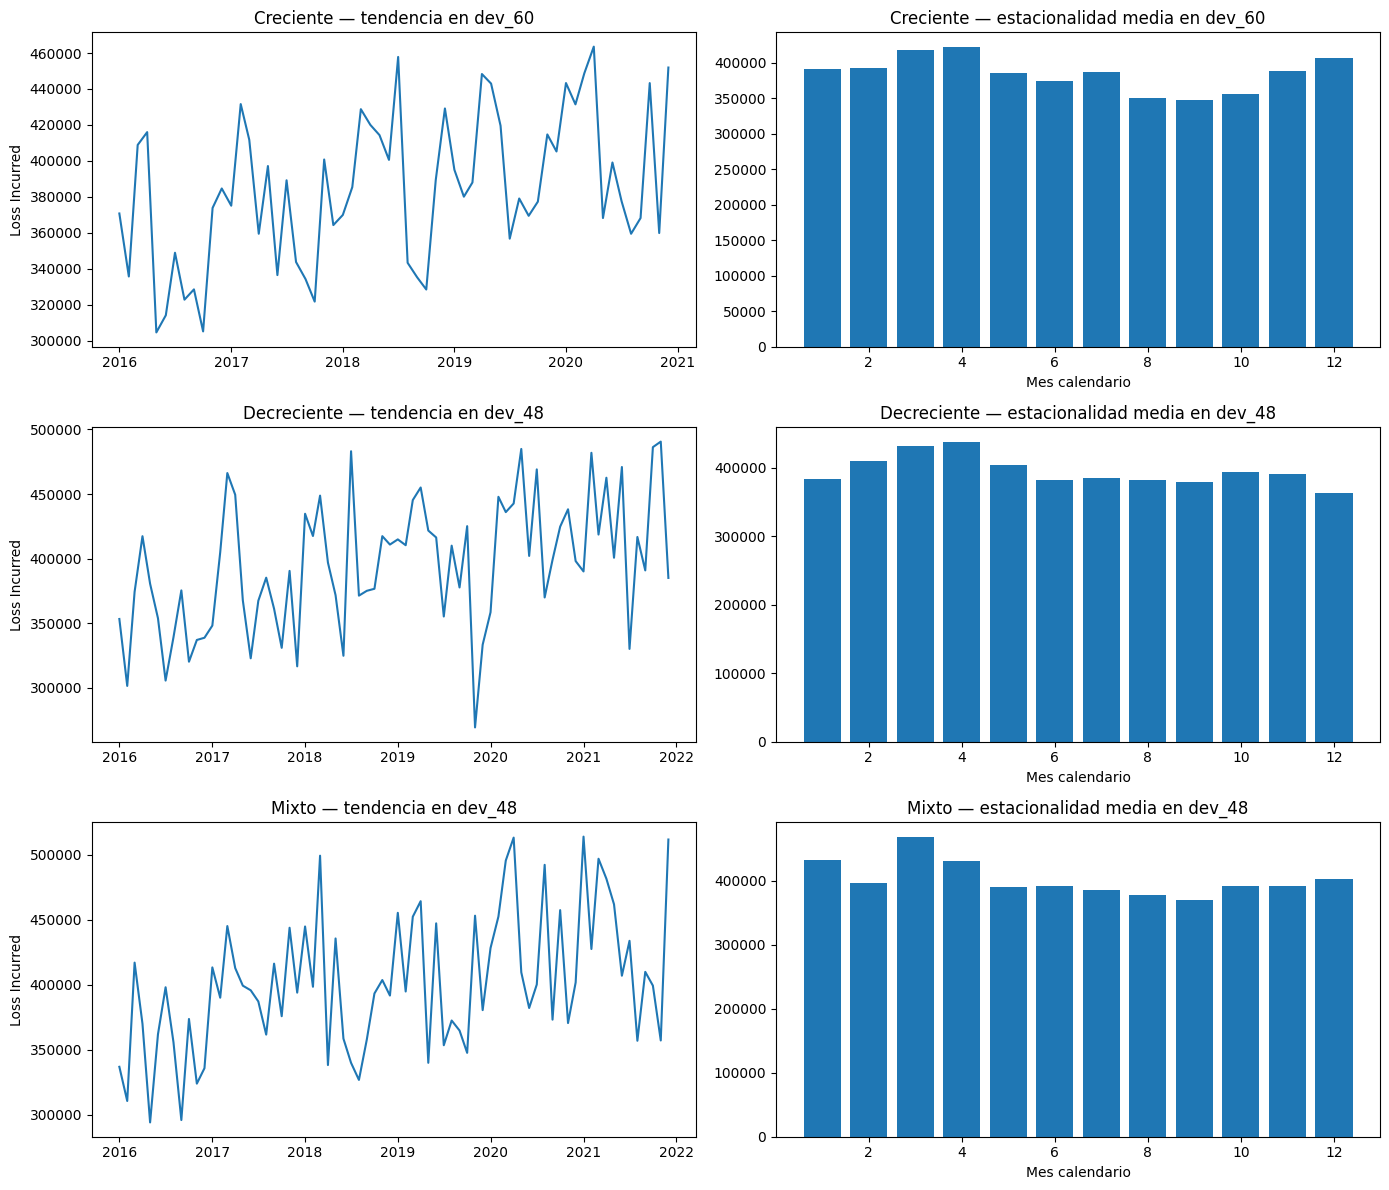

In [32]:
# Tendencia: valor observado en dev_M por período de ocurrencia.
# Estacionalidad: promedio del objetivo dev_M por mes calendario.

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, e in enumerate(bases):
    M = M_BY[e]
    objetivo = triangulos[e][M].dropna()
    objetivo.index = pd.PeriodIndex(objetivo.index, freq="M")

    axes[i, 0].plot(objetivo.index.to_timestamp(), objetivo.values)
    axes[i, 0].set_title(f"{e.capitalize()} — tendencia en dev_{M}")
    axes[i, 0].set_ylabel("Loss Incurred")

    estacional = pd.DataFrame({
        "mes": objetivo.index.month,
        "amount": objetivo.values,
    }).groupby("mes")["amount"].mean()

    axes[i, 1].bar(estacional.index, estacional.values)
    axes[i, 1].set_title(f"{e.capitalize()} — estacionalidad media en dev_{M}")
    axes[i, 1].set_xlabel("Mes calendario")

plt.tight_layout()
plt.show()

## 4. Diseño del backtesting cronológico

Para cada escenario:

1. Se corta la información a cada fecha histórica de valuación.
2. Se identifican períodos de ocurrencia con edad observada `< dev_M`.
3. La predicción se calcula usando solamente información disponible al corte.
4. La predicción queda **bloqueada** con la clave:
   `valuation_period + accident_period`.
5. El objetivo en `dev_M` se considera revelado únicamente cuando
   `accident_period + M <= fecha_de_evaluación`.
6. La fecha de evaluación final es diciembre de 2025.
7. Todos los métodos se comparan sobre la **intersección exacta de claves** con predicción válida en todos los modelos.

Las fechas de valuación son trimestrales entre junio de 2022 y diciembre de 2024. Esta frecuencia reduce redundancia computacional sin alterar el carácter cronológico del ejercicio.

## 5. Alternativas internas del Método de Desarrollo

Se comparan 18 alternativas:

- promedio simple (`S`) y ponderado por volumen (`VW`);
- ventanas de 12, 24 o todos los períodos disponibles;
- tres reglas:
  - sin exclusión;
  - excluir mínimo y máximo;
  - excluir factores fuera de ±2 desviaciones estándar.

Cada LDF se estima exclusivamente con las celdas observadas en la fecha histórica correspondiente.

In [33]:
CATALOGO = []

for metodo in ["S", "VW"]:
    for ventana in [12, 24, None]:
        for exclusion in ["none", "minmax", "std2"]:
            CATALOGO.append({
                "model": f"{metodo}_{'all' if ventana is None else ventana}_{exclusion}",
                "metodo": metodo,
                "ventana": ventana,
                "exclusion": exclusion,
            })

pd.DataFrame(CATALOGO)

,model,metodo,ventana,exclusion
0,S_12_none,S,12.0000,none
1,S_12_minmax,S,12.0000,minmax
2,S_12_std2,S,12.0000,std2
3,S_24_none,S,24.0000,none
4,S_24_minmax,S,24.0000,minmax
5,S_24_std2,S,24.0000,std2
6,S_all_none,S,NaN,none
7,S_all_minmax,S,NaN,minmax
8,S_all_std2,S,NaN,std2
9,VW_12_none,VW,12.0000,none


## 6. Alternativas GLM, Random Forest y XGBoost

Las variables explicativas se construyen únicamente con datos observables al corte:

- `latest_actual`;
- `latest_dev_age`;
- índice temporal del período de ocurrencia;
- seno/coseno del mes de ocurrencia;
- factor observado del último mes;
- crecimiento observado de los últimos tres meses.

Alternativas:

- `GLM_base`: Gamma/log con nivel, edad, tendencia y estacionalidad.
- `GLM_dinamica`: agrega dinámica reciente.
- `RF_prof6` y `RF_prof10`: dos profundidades de Random Forest.
- `XGB_d3` y `XGB_d5`: dos configuraciones de XGBoost.

El conjunto de entrenamiento de cada valuación usa únicamente snapshots anteriores cuyos objetivos `dev_M` ya habrían sido observables en esa fecha.

In [34]:
def cortar_matriz(matriz: np.ndarray, valuacion: str) -> np.ndarray:
    v = pd.Period(valuacion, freq="M")
    salida = matriz.copy()

    for i in range(N):
        edad = (v - (STARTP + i)).n
        if edad < 0:
            salida[i, :] = np.nan
        elif edad + 1 < salida.shape[1]:
            salida[i, edad + 1:] = np.nan

    return salida


def seleccionar_ldf_np(
    matriz: np.ndarray,
    M: int,
    metodo: str,
    ventana: int | None,
    exclusion: str,
) -> np.ndarray:
    resultado = np.full(M, np.nan)

    for j in range(M):
        origen = matriz[:, j]
        destino = matriz[:, j + 1]

        idx = np.where(
            np.isfinite(origen) & np.isfinite(destino) & (origen > 0)
        )[0]

        if ventana is not None:
            idx = idx[-ventana:]

        if len(idx) == 0:
            continue

        f = destino[idx] / origen[idx]
        conservar = np.ones(len(idx), dtype=bool)

        if exclusion == "minmax" and len(idx) > 2:
            conservar[np.argmin(f)] = False
            conservar[np.argmax(f)] = False

        elif exclusion == "std2" and len(idx) >= 3:
            media = f.mean()
            std = f.std(ddof=1)
            if std > 0:
                conservar = (
                    (f >= media - 2 * std)
                    & (f <= media + 2 * std)
                )

        idx2 = idx[conservar]
        f2 = f[conservar]

        if len(idx2) == 0:
            continue

        if metodo == "S":
            resultado[j] = f2.mean()
        else:
            resultado[j] = destino[idx2].sum() / origen[idx2].sum()

    return resultado


def construir_snapshots(
    matriz: np.ndarray,
    M: int,
    valuacion: str,
) -> pd.DataFrame:
    v = pd.Period(valuacion, freq="M")
    filas = []

    for i in range(N):
        ap = STARTP + i

        if ap > v:
            continue

        edad = min((v - ap).n, N - 1 - i)

        if edad < 0 or edad >= M:
            continue

        latest = matriz[i, edad]

        if not np.isfinite(latest):
            continue

        previo = matriz[i, edad - 1] if edad >= 1 else latest
        previo3 = matriz[i, edad - 3] if edad >= 3 else matriz[i, 0]

        filas.append({
            "valuation_period": str(v),
            "accident_period": str(ap),
            "target_valuation": str(ap + M),
            "ap_index": i,
            "latest_dev_age": edad,
            "latest_actual": latest,
            "last_factor": latest / previo if previo > 0 else 1.0,
            "growth_3": latest / previo3 if previo3 > 0 else 1.0,
            "ap_month": ap.month,
        })

    return pd.DataFrame(filas)


def mapa_objetivos(matriz: np.ndarray, M: int) -> dict:
    resultado = {}
    for i in range(N):
        if M <= N - 1 - i and np.isfinite(matriz[i, M]):
            resultado[str(STARTP + i)] = matriz[i, M]
    return resultado


def pronosticos_desarrollo(
    matriz: np.ndarray,
    M: int,
    valuacion: str,
) -> pd.DataFrame:
    corte = cortar_matriz(matriz, valuacion)
    snap = construir_snapshots(matriz, M, valuacion)

    if snap.empty:
        return pd.DataFrame()

    salidas = []

    for candidato in CATALOGO:
        ldf = seleccionar_ldf_np(
            corte,
            M,
            candidato["metodo"],
            candidato["ventana"],
            candidato["exclusion"],
        )

        pred = []

        for edad, latest in zip(
            snap["latest_dev_age"].values,
            snap["latest_actual"].values,
        ):
            edad = int(edad)
            restantes = ldf[edad:M]

            if (
                len(restantes) == M - edad
                and np.isfinite(restantes).all()
                and (restantes > 0).all()
            ):
                pred.append(latest * np.prod(restantes))
            else:
                pred.append(np.nan)

        z = snap.copy()
        z["model"] = candidato["model"]
        z["prediction"] = pred
        salidas.append(z)

    return pd.concat(salidas, ignore_index=True)


def frame_features(datos: pd.DataFrame, dinamico: bool = False) -> pd.DataFrame:
    mes = datos["ap_month"].to_numpy(float)

    X = pd.DataFrame({
        "log_latest": np.log(datos["latest_actual"].to_numpy(float)),
        "age": datos["latest_dev_age"].to_numpy(float),
        "ap_index": datos["ap_index"].to_numpy(float),
        "month_sin": np.sin(2 * np.pi * mes / 12),
        "month_cos": np.cos(2 * np.pi * mes / 12),
    }, index=datos.index)

    if dinamico:
        X["log_last_factor"] = np.log(
            np.clip(datos["last_factor"].to_numpy(float), 1e-8, None)
        )
        X["log_growth3"] = np.log(
            np.clip(datos["growth_3"].to_numpy(float), 1e-8, None)
        )

    return X


ML_MODELS = [
    "GLM_base",
    "GLM_dinamica",
    "RF_prof6",
    "RF_prof10",
    "XGB_d3",
    "XGB_d5",
]


def ajustar_predecir_ml(
    train: pd.DataFrame,
    test: pd.DataFrame,
    nombre_modelo: str,
) -> np.ndarray:
    dinamico = nombre_modelo in {
        "GLM_dinamica", "RF_prof10", "XGB_d5"
    }

    X_train = frame_features(train, dinamico)
    X_test = frame_features(test, dinamico)
    y_train = train["target"].to_numpy(float)

    # Evita que un mismo período de ocurrencia domine por aparecer
    # en varios snapshots históricos.
    pesos = (
        1
        / train.groupby("accident_period")["accident_period"]
        .transform("size")
        .to_numpy(float)
    )

    if nombre_modelo.startswith("GLM"):
        X_train = sm.add_constant(X_train, has_constant="add")
        X_test = sm.add_constant(X_test, has_constant="add")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            modelo = sm.GLM(
                y_train,
                X_train,
                family=sm.families.Gamma(sm.families.links.Log()),
                var_weights=pesos,
            ).fit(maxiter=100, disp=0)

        return np.asarray(modelo.predict(X_test))

    if nombre_modelo == "RF_prof6":
        modelo = RandomForestRegressor(
            n_estimators=50,
            max_depth=6,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=2,
        )

    elif nombre_modelo == "RF_prof10":
        modelo = RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=2,
        )

    elif nombre_modelo == "XGB_d3":
        modelo = XGBRegressor(
            n_estimators=50,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.90,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=2,
        )

    else:
        modelo = XGBRegressor(
            n_estimators=50,
            max_depth=5,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.90,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=2,
        )

    modelo.fit(X_train, y_train, sample_weight=pesos)
    return modelo.predict(X_test)

## 7. Ejecución del backtesting sin información futura

Esta es la parte central del ejercicio. En cada fecha:

- se recalculan los LDF con el corte histórico;
- los modelos ML se entrenan sólo con snapshots cuyo objetivo ya estaba revelado;
- se bloquean predicciones para períodos todavía inmaduros;
- el objetivo sólo se usa después para scoring.

In [35]:
def ejecutar_backtesting(
    escenario: str,
    matriz: np.ndarray,
    M: int,
):
    objetivos = mapa_objetivos(matriz, M)

    snapshots_hist = pd.concat(
        [construir_snapshots(matriz, M, v) for v in PRELIMINARES],
        ignore_index=True,
    )
    snapshots_hist["target"] = snapshots_hist["accident_period"].map(objetivos)

    desarrollo = pd.concat(
        [pronosticos_desarrollo(matriz, M, v) for v in VALUACIONES],
        ignore_index=True,
    )
    desarrollo["target"] = desarrollo["accident_period"].map(objetivos)

    salidas = [
        desarrollo[
            [
                "valuation_period",
                "accident_period",
                "target_valuation",
                "model",
                "prediction",
                "target",
                "latest_actual",
                "latest_dev_age",
            ]
        ].copy()
    ]

    for valuacion in VALUACIONES:
        vp = pd.Period(valuacion, freq="M")

        forecast_period = snapshots_hist["valuation_period"].map(
            lambda x: pd.Period(x, freq="M")
        )
        target_period = snapshots_hist["target_valuation"].map(
            lambda x: pd.Period(x, freq="M")
        )

        train = snapshots_hist[
            (forecast_period < vp)
            & (target_period <= vp)
        ].dropna(subset=["target"]).copy()

        test = construir_snapshots(matriz, M, valuacion)
        test["target"] = test["accident_period"].map(objetivos)

        test = test[
            test["target_valuation"].map(
                lambda x: pd.Period(x, freq="M")
            ) <= EVALP
        ].dropna(subset=["target"]).copy()

        if len(train) < 40 or test.empty:
            continue

        for nombre in ML_MODELS:
            try:
                pred = ajustar_predecir_ml(train, test, nombre)
            except Exception:
                continue

            z = test[
                [
                    "valuation_period",
                    "accident_period",
                    "target_valuation",
                    "target",
                    "latest_actual",
                    "latest_dev_age",
                ]
            ].copy()

            z["model"] = nombre
            z["prediction"] = pred
            salidas.append(z)

    pred = pd.concat(salidas, ignore_index=True)

    pred = pred[
        pred["target_valuation"].map(
            lambda x: pd.Period(x, freq="M")
        ) <= EVALP
    ].dropna(subset=["target", "prediction"])

    # Intersección exacta de claves para comparación pareada.
    key_cols = ["valuation_period", "accident_period"]
    n_modelos = pred["model"].nunique()

    conteos = pred.groupby(key_cols)["model"].nunique()
    llaves_comunes = set(conteos[conteos == n_modelos].index)

    mask = [
        (v, ap) in llaves_comunes
        for v, ap in zip(
            pred["valuation_period"],
            pred["accident_period"],
        )
    ]

    paired = pred.loc[mask].copy()

    def metricas(g):
        error = g["prediction"] - g["target"]

        return pd.Series({
            "n_scored": len(g),
            "WAPE": (
                100
                * np.abs(error).sum()
                / np.abs(g["target"]).sum()
            ),
            "Bias_pct": (
                100
                * error.sum()
                / g["target"].sum()
            ),
            "RMSE": np.sqrt(np.mean(error ** 2)),
            "Reserve_error": error.sum(),
        })

    resumen = (
        paired.groupby("model", sort=False)
        .apply(metricas, include_groups=False)
        .reset_index()
    )

    por_fecha = (
        paired.groupby(["model", "valuation_period"])
        .apply(
            lambda g:
            100
            * np.abs(g["prediction"] - g["target"]).sum()
            / np.abs(g["target"]).sum(),
            include_groups=False,
        )
        .rename("WAPE_val")
        .reset_index()
    )

    estabilidad = (
        por_fecha.groupby("model")["WAPE_val"]
        .agg(["mean", "std", "max"])
        .reset_index()
        .rename(columns={
            "mean": "WAPE_mean_dates",
            "std": "WAPE_stability_sd",
            "max": "WAPE_worst",
        })
    )

    resumen = resumen.merge(estabilidad, on="model")

    return pred, paired, resumen, por_fecha


resultados = {}

for escenario, matriz in matrices.items():
    resultados[escenario] = ejecutar_backtesting(
        escenario,
        matriz,
        M_BY[escenario],
    )

    _, paired, resumen, _ = resultados[escenario]

    print("\n", "=" * 90)
    print(escenario.upper())
    print("Observaciones comunes por modelo:", paired.groupby("model").size().iloc[0])
    print("Número de modelos:", resumen["model"].nunique())
    display(resumen.sort_values("WAPE").head(10))


CRECIENTE
Observaciones comunes por modelo: 297
Número de modelos: 24


,model,n_scored,WAPE,Bias_pct,RMSE,Reserve_error,WAPE_mean_dates,WAPE_stability_sd,WAPE_worst
3,S_24_none,297.0000,0.3803,-0.1077,"2,745.9207","-128,006.1908",0.3201,0.1872,0.6500
12,VW_24_none,297.0000,0.3833,-0.1182,"2,768.8142","-140,525.9649",0.3230,0.1872,0.6494
4,S_24_minmax,297.0000,0.3833,-0.1214,"2,763.8096","-144,297.0946",0.3231,0.1870,0.6490
0,S_12_none,297.0000,0.3868,-0.0945,"2,793.6549","-112,404.2013",0.3262,0.1881,0.6589
13,VW_24_minmax,297.0000,0.3871,-0.1364,"2,792.3616","-162,205.7165",0.3265,0.1879,0.6504
1,S_12_minmax,297.0000,0.3878,-0.1063,"2,791.2641","-126,446.1878",0.3276,0.1869,0.6578
6,S_all_none,297.0000,0.3890,-0.1323,"2,823.4498","-157,342.9278",0.3282,0.1884,0.6518
9,VW_12_none,297.0000,0.3896,-0.1064,"2,811.3061","-126,562.5903",0.3290,0.1883,0.6585
10,VW_12_minmax,297.0000,0.3903,-0.1171,"2,808.6732","-139,285.5879",0.3299,0.1874,0.6580
2,S_12_std2,297.0000,0.3914,-0.1177,"2,808.3912","-139,960.1365",0.3320,0.1844,0.6569



DECRECIENTE
Observaciones comunes por modelo: 297
Número de modelos: 24


,model,n_scored,WAPE,Bias_pct,RMSE,Reserve_error,WAPE_mean_dates,WAPE_stability_sd,WAPE_worst
6,S_all_none,297.0000,0.2785,0.0845,"1,898.8467","104,725.0157",0.2380,0.1261,0.4540
7,S_all_minmax,297.0000,0.2787,0.0885,"1,900.7809","109,718.0443",0.2385,0.1253,0.4533
8,S_all_std2,297.0000,0.2792,0.1002,"1,911.6496","124,202.2431",0.2396,0.1230,0.4512
15,VW_all_none,297.0000,0.2792,0.0888,"1,907.4305","110,108.8072",0.2388,0.1257,0.4540
16,VW_all_minmax,297.0000,0.2794,0.0913,"1,907.9691","113,189.9854",0.2392,0.1250,0.4536
17,VW_all_std2,297.0000,0.2800,0.1024,"1,918.3584","126,967.5756",0.2404,0.1229,0.4515
0,S_12_none,297.0000,0.2839,0.1372,"2,010.5411","170,106.4347",0.2437,0.1246,0.4476
3,S_24_none,297.0000,0.2876,0.1262,"2,011.6462","156,514.8927",0.2468,0.1265,0.4543
9,VW_12_none,297.0000,0.2884,0.1522,"2,046.0681","188,740.6838",0.2478,0.1256,0.4493
1,S_12_minmax,297.0000,0.2913,0.1616,"2,064.4696","200,323.8850",0.2508,0.1253,0.4503



MIXTO
Observaciones comunes por modelo: 297
Número de modelos: 24


,model,n_scored,WAPE,Bias_pct,RMSE,Reserve_error,WAPE_mean_dates,WAPE_stability_sd,WAPE_worst
3,S_24_none,297.0000,0.4885,-0.0383,"3,357.5375","-48,480.3527",0.4264,0.1928,0.7255
4,S_24_minmax,297.0000,0.4889,-0.0344,"3,360.3239","-43,495.9739",0.4267,0.1928,0.7234
8,S_all_std2,297.0000,0.4900,-0.0409,"3,373.8808","-51,727.6506",0.4259,0.1989,0.7219
13,VW_24_minmax,297.0000,0.4900,-0.0472,"3,365.4197","-59,645.5300",0.4278,0.1930,0.7217
5,S_24_std2,297.0000,0.4901,-0.0142,"3,369.5233","-17,932.0728",0.4278,0.1930,0.7268
12,VW_24_none,297.0000,0.4908,-0.0558,"3,366.9695","-70,539.3016",0.4283,0.1938,0.7251
17,VW_all_std2,297.0000,0.4909,-0.0502,"3,377.0275","-63,517.7895",0.4266,0.1995,0.7212
14,VW_24_std2,297.0000,0.4913,-0.0307,"3,374.8438","-38,890.1327",0.4291,0.1930,0.7227
7,S_all_minmax,297.0000,0.4914,-0.0579,"3,378.1821","-73,223.9913",0.4266,0.2010,0.7284
6,S_all_none,297.0000,0.4918,-0.0615,"3,379.0662","-77,855.0109",0.4268,0.2017,0.7309


## 8. Verificación de población comparable y métricas

Se exige que cada modelo tenga exactamente las mismas claves de evaluación dentro de cada escenario.  
Las métricas utilizadas son:

\[
WAPE = \frac{\sum_i |\hat y_i-y_i|}{\sum_i |y_i|}\times 100
\]

\[
Bias\% = \frac{\sum_i(\hat y_i-y_i)}{\sum_i y_i}\times100
\]

Además se reportan RMSE, error agregado de reserva y desviación estándar del WAPE entre fechas de valuación.

In [36]:
for escenario in resultados:
    _, paired, resumen, por_fecha = resultados[escenario]

    conteo = paired.groupby("model").size()
    assert conteo.nunique() == 1

    print("\n", escenario.upper())
    print("Todos los modelos tienen las mismas claves:", conteo.nunique() == 1)
    print("n por modelo:", conteo.iloc[0])

    tabla = resumen.sort_values(
        ["WAPE", "WAPE_stability_sd", "Bias_pct"],
        key=lambda s: s.abs() if s.name == "Bias_pct" else s,
    )

    display(tabla)


 CRECIENTE
Todos los modelos tienen las mismas claves: True
n por modelo: 297


,model,n_scored,WAPE,Bias_pct,RMSE,Reserve_error,WAPE_mean_dates,WAPE_stability_sd,WAPE_worst
3,S_24_none,297.0000,0.3803,-0.1077,"2,745.9207","-128,006.1908",0.3201,0.1872,0.6500
12,VW_24_none,297.0000,0.3833,-0.1182,"2,768.8142","-140,525.9649",0.3230,0.1872,0.6494
4,S_24_minmax,297.0000,0.3833,-0.1214,"2,763.8096","-144,297.0946",0.3231,0.1870,0.6490
0,S_12_none,297.0000,0.3868,-0.0945,"2,793.6549","-112,404.2013",0.3262,0.1881,0.6589
13,VW_24_minmax,297.0000,0.3871,-0.1364,"2,792.3616","-162,205.7165",0.3265,0.1879,0.6504
1,S_12_minmax,297.0000,0.3878,-0.1063,"2,791.2641","-126,446.1878",0.3276,0.1869,0.6578
6,S_all_none,297.0000,0.3890,-0.1323,"2,823.4498","-157,342.9278",0.3282,0.1884,0.6518
9,VW_12_none,297.0000,0.3896,-0.1064,"2,811.3061","-126,562.5903",0.3290,0.1883,0.6585
10,VW_12_minmax,297.0000,0.3903,-0.1171,"2,808.6732","-139,285.5879",0.3299,0.1874,0.6580
2,S_12_std2,297.0000,0.3914,-0.1177,"2,808.3912","-139,960.1365",0.3320,0.1844,0.6569



 DECRECIENTE
Todos los modelos tienen las mismas claves: True
n por modelo: 297


,model,n_scored,WAPE,Bias_pct,RMSE,Reserve_error,WAPE_mean_dates,WAPE_stability_sd,WAPE_worst
6,S_all_none,297.0000,0.2785,0.0845,"1,898.8467","104,725.0157",0.2380,0.1261,0.4540
7,S_all_minmax,297.0000,0.2787,0.0885,"1,900.7809","109,718.0443",0.2385,0.1253,0.4533
8,S_all_std2,297.0000,0.2792,0.1002,"1,911.6496","124,202.2431",0.2396,0.1230,0.4512
15,VW_all_none,297.0000,0.2792,0.0888,"1,907.4305","110,108.8072",0.2388,0.1257,0.4540
16,VW_all_minmax,297.0000,0.2794,0.0913,"1,907.9691","113,189.9854",0.2392,0.1250,0.4536
17,VW_all_std2,297.0000,0.2800,0.1024,"1,918.3584","126,967.5756",0.2404,0.1229,0.4515
0,S_12_none,297.0000,0.2839,0.1372,"2,010.5411","170,106.4347",0.2437,0.1246,0.4476
3,S_24_none,297.0000,0.2876,0.1262,"2,011.6462","156,514.8927",0.2468,0.1265,0.4543
9,VW_12_none,297.0000,0.2884,0.1522,"2,046.0681","188,740.6838",0.2478,0.1256,0.4493
1,S_12_minmax,297.0000,0.2913,0.1616,"2,064.4696","200,323.8850",0.2508,0.1253,0.4503



 MIXTO
Todos los modelos tienen las mismas claves: True
n por modelo: 297


,model,n_scored,WAPE,Bias_pct,RMSE,Reserve_error,WAPE_mean_dates,WAPE_stability_sd,WAPE_worst
3,S_24_none,297.0000,0.4885,-0.0383,"3,357.5375","-48,480.3527",0.4264,0.1928,0.7255
4,S_24_minmax,297.0000,0.4889,-0.0344,"3,360.3239","-43,495.9739",0.4267,0.1928,0.7234
8,S_all_std2,297.0000,0.4900,-0.0409,"3,373.8808","-51,727.6506",0.4259,0.1989,0.7219
13,VW_24_minmax,297.0000,0.4900,-0.0472,"3,365.4197","-59,645.5300",0.4278,0.1930,0.7217
5,S_24_std2,297.0000,0.4901,-0.0142,"3,369.5233","-17,932.0728",0.4278,0.1930,0.7268
12,VW_24_none,297.0000,0.4908,-0.0558,"3,366.9695","-70,539.3016",0.4283,0.1938,0.7251
17,VW_all_std2,297.0000,0.4909,-0.0502,"3,377.0275","-63,517.7895",0.4266,0.1995,0.7212
14,VW_24_std2,297.0000,0.4913,-0.0307,"3,374.8438","-38,890.1327",0.4291,0.1930,0.7227
7,S_all_minmax,297.0000,0.4914,-0.0579,"3,378.1821","-73,223.9913",0.4266,0.2010,0.7284
6,S_all_none,297.0000,0.4918,-0.0615,"3,379.0662","-77,855.0109",0.4268,0.2017,0.7309


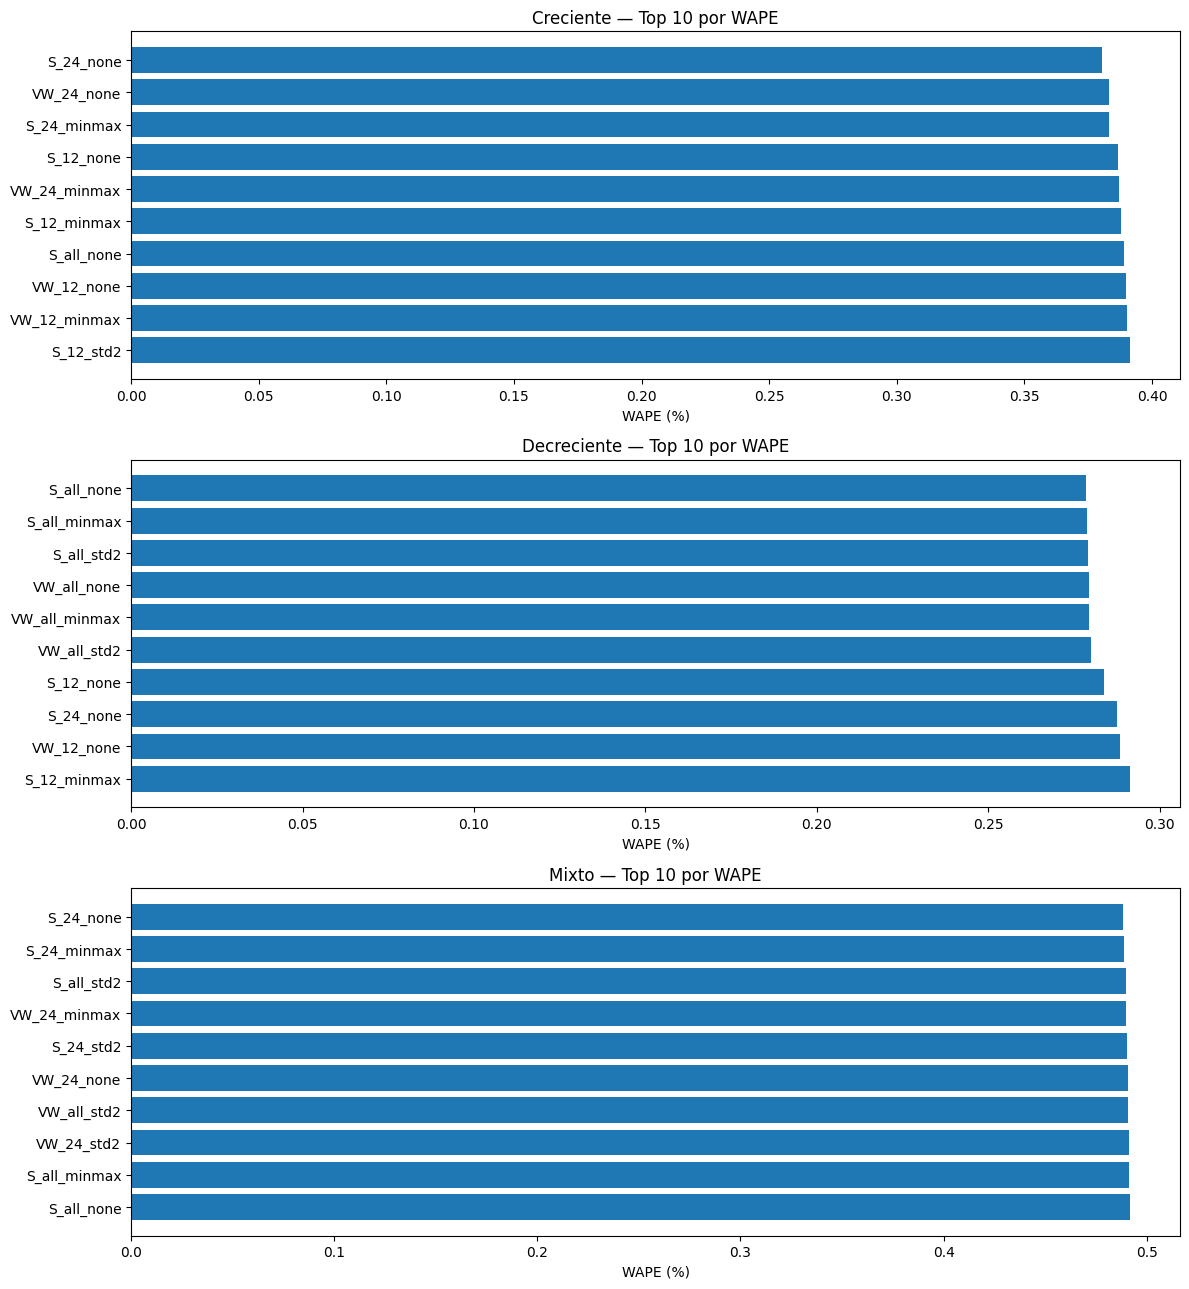

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(12, 13))

for ax, escenario in zip(axes, resultados):
    _, _, resumen, _ = resultados[escenario]

    top = resumen.sort_values("WAPE").head(10)
    ax.barh(top["model"][::-1], top["WAPE"][::-1])
    ax.set_title(f"{escenario.capitalize()} — Top 10 por WAPE")
    ax.set_xlabel("WAPE (%)")

plt.tight_layout()
plt.show()

## 9. Selección del método preferido por escenario

El criterio principal es WAPE fuera de muestra, pero se revisan también:

- sesgo agregado;
- estabilidad entre fechas;
- razonabilidad actuarial;
- interpretabilidad.

No se selecciona automáticamente un modelo de machine learning por ser más sofisticado. Si un método de desarrollo obtiene error igual o menor y reproduce correctamente la dirección de los factores, se prefiere por transparencia.

In [38]:
seleccion = {}

for escenario in resultados:
    resumen = resultados[escenario][2].copy()
    mejor = resumen.sort_values(
        ["WAPE", "WAPE_stability_sd"]
    ).iloc[0]

    seleccion[escenario] = mejor["model"]

tabla_seleccion = pd.DataFrame([
    {
        "escenario": e,
        "dev_M": M_BY[e],
        "metodo_seleccionado": seleccion[e],
        **resultados[e][2]
        .set_index("model")
        .loc[seleccion[e], [
            "WAPE",
            "Bias_pct",
            "RMSE",
            "Reserve_error",
            "WAPE_stability_sd",
        ]]
        .to_dict(),
    }
    for e in seleccion
])

tabla_seleccion

,escenario,dev_M,metodo_seleccionado,WAPE,Bias_pct,RMSE,Reserve_error,WAPE_stability_sd
0,creciente,60,S_24_none,0.3803,-0.1077,"2,745.9207","-128,006.1908",0.1872
1,decreciente,48,S_all_none,0.2785,0.0845,"1,898.8467","104,725.0157",0.1261
2,mixto,48,S_24_none,0.4885,-0.0383,"3,357.5375","-48,480.3527",0.1928


### Justificación actuarial

La selección se basa primero en desempeño fuera de muestra y después se contrasta con estabilidad, sesgo e interpretabilidad. Un método de Desarrollo tiene ventaja explicativa cuando su desempeño es comparable, porque permite rastrear directamente los factores edad-a-edad. Un modelo GLM/RF/XGBoost sólo se conserva como preferido si su mejora predictiva compensa esa menor transparencia.

La tabla anterior documenta qué método resulta preferido en cada escenario bajo estas reglas.

## 10. Aplicación del método seleccionado a la valuación actual

La reserva reportada es la diferencia entre la predicción a `dev_M` y el último acumulado observado para los períodos todavía inmaduros.

Por ello:

- puede ser positiva en un escenario creciente;
- puede ser negativa en un escenario decreciente (liberación);
- puede estar cerca de cero o cambiar de signo en un escenario mixto.

In [39]:
def aplicar_metodo_actual(
    escenario: str,
    matriz: np.ndarray,
    M: int,
    model_id: str,
    valuacion: str = "2025-12",
):
    snap = construir_snapshots(matriz, M, valuacion)

    # Caso 1: método de Desarrollo
    candidatos_ids = {c["model"] for c in CATALOGO}

    if model_id in candidatos_ids:
        candidato = next(
            c for c in CATALOGO
            if c["model"] == model_id
        )

        corte = cortar_matriz(matriz, valuacion)

        ldf = seleccionar_ldf_np(
            corte,
            M,
            candidato["metodo"],
            candidato["ventana"],
            candidato["exclusion"],
        )

        pred = []
        for edad, latest in zip(
            snap["latest_dev_age"],
            snap["latest_actual"],
        ):
            edad = int(edad)
            pred.append(
                latest * np.prod(ldf[edad:M])
            )

    # Caso 2: GLM / RF / XGBoost
    else:
        objetivos = mapa_objetivos(matriz, M)

        hist = pd.concat(
            [construir_snapshots(matriz, M, v) for v in PRELIMINARES],
            ignore_index=True,
        )
        hist["target"] = hist["accident_period"].map(objetivos)

        vp = pd.Period(valuacion, freq="M")
        hist = hist[
            hist["target_valuation"].map(
                lambda x: pd.Period(x, freq="M")
            ) <= vp
        ].dropna(subset=["target"]).copy()

        pred = ajustar_predecir_ml(
            hist,
            snap,
            model_id,
        )
        ldf = None

    salida = snap.copy()
    salida["prediction_dev_M"] = pred
    salida["reserve_to_dev_M"] = (
        salida["prediction_dev_M"]
        - salida["latest_actual"]
    )

    return salida, ldf


aplicacion_actual = {}
resumen_reservas = []

for escenario in seleccion:
    salida, ldf = aplicar_metodo_actual(
        escenario,
        matrices[escenario],
        M_BY[escenario],
        seleccion[escenario],
    )

    aplicacion_actual[escenario] = (salida, ldf)

    resumen_reservas.append({
        "escenario": escenario,
        "dev_M": M_BY[escenario],
        "metodo": seleccion[escenario],
        "n_periodos_inmaduros": len(salida),
        "observado_actual": salida["latest_actual"].sum(),
        "estimado_dev_M": salida["prediction_dev_M"].sum(),
        "reserva_hasta_dev_M": salida["reserve_to_dev_M"].sum(),
    })

resumen_reservas = pd.DataFrame(resumen_reservas)
resumen_reservas

,escenario,dev_M,metodo,n_periodos_inmaduros,observado_actual,estimado_dev_M,reserva_hasta_dev_M
0,creciente,60,S_24_none,60,"19,986,138.5279","26,834,083.2548","6,847,944.7269"
1,decreciente,48,S_all_none,48,"23,690,837.7631","22,122,210.5483","-1,568,627.2147"
2,mixto,48,S_24_none,48,"22,000,232.2048","22,211,143.2390","210,911.0342"


In [40]:
# Diagnóstico de factores seleccionados.
# Para modelos ML no existe una secuencia LDF única; se reporta NaN.

diagnostico_factores = []

for escenario, (salida, ldf) in aplicacion_actual.items():
    M = M_BY[escenario]

    if ldf is None:
        diagnostico_factores.append({
            "escenario": escenario,
            "factor_mediano_0_17": np.nan,
            "factor_mediano_18_M": np.nan,
            "pct_ldf_gt_1": np.nan,
            "pct_ldf_lt_1": np.nan,
        })
    else:
        diagnostico_factores.append({
            "escenario": escenario,
            "factor_mediano_0_17": np.nanmedian(ldf[:min(18, M)]),
            "factor_mediano_18_M": (
                np.nanmedian(ldf[18:M])
                if M > 18 else np.nan
            ),
            "pct_ldf_gt_1": 100 * np.mean(ldf > 1),
            "pct_ldf_lt_1": 100 * np.mean(ldf < 1),
        })

diagnostico_factores = pd.DataFrame(diagnostico_factores)
diagnostico_factores

,escenario,factor_mediano_0_17,factor_mediano_18_M,pct_ldf_gt_1,pct_ldf_lt_1
0,creciente,1.0781,1.0046,100.0000,0.0000
1,decreciente,0.9908,0.9982,0.0000,100.0000
2,mixto,1.0199,0.9978,37.5000,62.5000


## 11. Supuestos y limitaciones

1. Los datos son sintéticos y, por construcción, tienen un patrón más estable que una cartera real.
2. `dev_M` es una madurez fija para evaluación y backtesting, no ultimate infinito.
3. No se incorpora tail posterior a `dev_M`.
4. Los factores pueden ser menores que 1; no se fuerzan artificialmente a 1 porque los escenarios decreciente y mixto requieren permitir liberaciones.
5. En los escenarios decreciente/mixto, los incrementales negativos son una consecuencia legítima de ajustes a la baja del acumulado.
6. Las valuaciones se hacen trimestralmente para evitar redundancia; la base y el desarrollo siguen siendo mensuales.
7. Random Forest y XGBoost ofrecen flexibilidad, pero tienen menor interpretabilidad actuarial que un método de desarrollo.
8. La selección final depende de esta simulación y de este período de backtesting; no debe generalizarse a otra cartera sin repetir el ejercicio.

In [41]:
# Comparación final entre escenarios

comparacion_final = tabla_seleccion.merge(
    resumen_reservas,
    on=["escenario", "dev_M"],
    suffixes=("_backtest", "_actual"),
)

comparacion_final[
    [
        "escenario",
        "dev_M",
        "metodo_seleccionado",
        "WAPE",
        "Bias_pct",
        "WAPE_stability_sd",
        "n_periodos_inmaduros",
        "observado_actual",
        "estimado_dev_M",
        "reserva_hasta_dev_M",
    ]
]

,escenario,dev_M,metodo_seleccionado,WAPE,Bias_pct,WAPE_stability_sd,n_periodos_inmaduros,observado_actual,estimado_dev_M,reserva_hasta_dev_M
0,creciente,60,S_24_none,0.3803,-0.1077,0.1872,60,"19,986,138.5279","26,834,083.2548","6,847,944.7269"
1,decreciente,48,S_all_none,0.2785,0.0845,0.1261,48,"23,690,837.7631","22,122,210.5483","-1,568,627.2147"
2,mixto,48,S_24_none,0.4885,-0.0383,0.1928,48,"22,000,232.2048","22,211,143.2390","210,911.0342"


## 12. Conclusiones

El backtesting confirma que la dirección del desarrollo importa para la interpretación de reservas:

- En el **escenario creciente**, el método seleccionado proyecta montos mayores que la diagonal actual y genera una **reserva positiva**.
- En el **escenario decreciente**, los LDF menores que 1 proyectan una reducción futura y producen una **reserva negativa / liberación**.
- En el **escenario mixto**, los factores cambian de dirección: son mayores que 1 en etapas tempranas y menores que 1 posteriormente. La reserva agregada a la madurez es mucho menor en magnitud porque ambos efectos se compensan parcialmente.

La comparación fuera de muestra permite identificar si la estructura por edad del triángulo es suficiente o si un modelo predictivo añade valor. La tabla de selección debe leerse junto con sesgo, estabilidad e interpretabilidad; la menor WAPE no se interpreta de forma aislada.

La elección final debe entenderse como específica a cada escenario, a su `dev_M`, al período histórico utilizado y a las reglas de backtesting definidas.

In [42]:
# Exportación opcional de las tres bases y resultados principales.
salidas = Path("salidas")
salidas.mkdir(exist_ok=True)

for escenario, base in bases.items():
    base.to_csv(
        salidas / f"base_{escenario}.csv",
        index=False,
    )

tabla_seleccion.to_csv(
    salidas / "seleccion_metodos.csv",
    index=False,
)

resumen_reservas.to_csv(
    salidas / "reservas_finales.csv",
    index=False,
)

print("Archivos exportados en:", salidas.resolve())

Archivos exportados en: C:\Users\derec\Desktop\Diplomado\ml-insurance-team-lab\M4\salidas
